📊 Dataset Preview:
    distance_km  time_min  traffic_level  price  price_per_km
0             2         5              1     60     30.000000
1             3         8              1     80     26.666667
2             5        12              2    120     24.000000
3             7        15              2    160     22.857143
4            10        20              3    220     22.000000
5            12        25              3    270     22.500000
6            15        30              3    330     22.000000
7            18        35              4    400     22.222222
8            20        40              4    450     22.500000
9            25        50              5    550     22.000000
10           30        60              5    700     23.333333
11           35        70              5    850     24.285714

📈 MODEL PERFORMANCE:
MAE: 29.033333333333342
MSE: 1210.8700000000006
R2 Score: 0.983787816126153


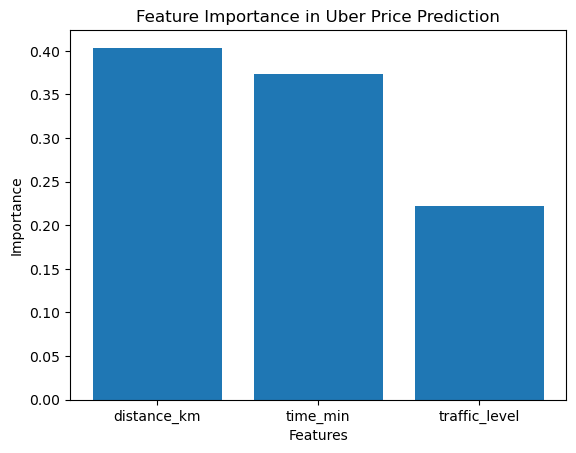


🚕 Uber Ride Price Prediction System
------------------------------------


Enter distance in KM:  50
Enter time in minutes:  90
Enter traffic level (1-5):  3



💰 Estimated Ride Fare: 592.50 PKR


In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


# ==============================
# 2. CREATE DATASET
# ==============================
data = {
    "distance_km": [2, 3, 5, 7, 10, 12, 15, 18, 20, 25, 30, 35],
    "time_min":    [5, 8, 12, 15, 20, 25, 30, 35, 40, 50, 60, 70],
    "traffic_level":[1, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 5],
    "price":       [60, 80, 120, 160, 220, 270, 330, 400, 450, 550, 700, 850]
}

df = pd.DataFrame(data)

# Optional feature engineering (for realism)
df["price_per_km"] = df["price"] / df["distance_km"]

print("📊 Dataset Preview:")
print(df)


# ==============================
# 3. SPLIT FEATURES & TARGET
# ==============================
X = df[["distance_km", "time_min", "traffic_level"]]
y = df["price"]


# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 5. TRAIN MODEL
# ==============================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ==============================
# 6. MODEL EVALUATION
# ==============================
y_pred = model.predict(X_test)

print("\n📈 MODEL PERFORMANCE:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


# ==============================
# 7. FEATURE IMPORTANCE
# ==============================
features = ["distance_km", "time_min", "traffic_level"]

plt.bar(features, model.feature_importances_)
plt.title("Feature Importance in Uber Price Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


# ==============================
# 8. USER INPUT (FIXED - NO WARNING)
# ==============================
print("\n🚕 Uber Ride Price Prediction System")
print("------------------------------------")

distance = float(input("Enter distance in KM: "))
time = float(input("Enter time in minutes: "))
traffic = int(input("Enter traffic level (1-5): "))

# ✅ FIXED PART (IMPORTANT)
input_data = pd.DataFrame(
    [[distance, time, traffic]],
    columns=["distance_km", "time_min", "traffic_level"]
)

prediction = model.predict(input_data)

print("\n==============================")
print(f"💰 Estimated Ride Fare: {prediction[0]:.2f} PKR")
print("==============================")